In [9]:
import json
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow import keras
from TheModelFinalFinalV2 import build
from tqdm import tqdm
from tensorflow.keras.models import load_model

_, (x_test, y_test) = keras.datasets.mnist.load_data()
x_test = np.expand_dims(x_test, -1) / 255.0  

In [11]:
n= 5 #cantidad de integrantes
local_models = []
for i in range(n):
    local_model = load_model(f'local_model_{i}.keras')  
    local_models.append(local_model)

# FedAvg
local_weights = [model.get_weights() for model in local_models]
averaged_weights = [np.mean(np.array(weights), axis=0) for weights in zip(*local_weights)]
global_model = build.build_it()
global_model.set_weights(averaged_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Resultados del modelo global:")
print(classification_report(y_test, y_pred_classes))
global_model.save('global_model_FedAvg.keras')


ValueError: You called `set_weights(weights)` on layer "sequential_4" with a weight list of length 20, but the layer was expecting 8 weights. Provided weights: [array([[[[-0.00722166, -0.04190158,  0.05626993, ...

In [6]:
#Prueba de FedProx

local_weights = [model.get_weights() for model in local_models]
averaged_weights = [np.mean(np.array(weights), axis=0) for weights in zip(*local_weights)]

r = 0.1  
global_weights = averaged_weights.copy()
for i in range(len(averaged_weights)):
    global_weights[i] = averaged_weights[i] - r * (averaged_weights[i] - local_weights[0][i])


global_model.set_weights(global_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

global_model.save('global_model_Fedprox.keras')


ValueError: You called `set_weights(weights)` on layer "sequential" with a weight list of length 20, but the layer was expecting 8 weights. Provided weights: [array([[[[-0.03705562,  0.03016628, -0.03749441, ...

In [ ]:
#Prueba de FedMax

local_weights = [model.get_weights() for model in local_models]

max_weights = []
for i in range(len(local_weights[0])):
    max_weight = np.max([local_weights[j][i] for j in range(len(local_weights))], axis=0)
    max_weights.append(max_weight)

global_model.set_weights(max_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

global_model.save('global_model_Fedmax.keras')


Epoch 1/5


1875/1875 [==============================] - 40s 20ms/step - loss: 0.1717 - accuracy: 0.9478 - val_loss: 0.0486 - val_accuracy: 0.9840
Epoch 2/5
1875/1875 [==============================] - 45s 24ms/step - loss: 0.0642 - accuracy: 0.9804 - val_loss: 0.0403 - val_accuracy: 0.9870
Epoch 3/5
1875/1875 [==============================] - 49s 26ms/step - loss: 0.0487 - accuracy: 0.9845 - val_loss: 0.0381 - val_accuracy: 0.9872
Epoch 4/5
1875/1875 [==============================] - 43s 23ms/step - loss: 0.0387 - accuracy: 0.9875 - val_loss: 0.0355 - val_accuracy: 0.9883
Epoch 5/5
313/313 [==============================] - 3s 8ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99     

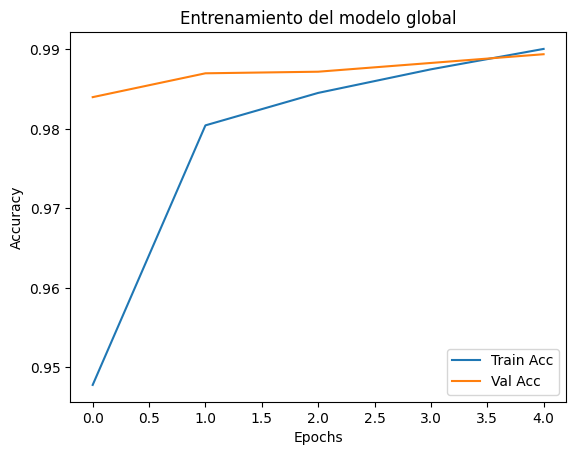

In [4]:
#Modelo general comparativa sin segmentacion (aprendizaje federado)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1).astype(np.float32) / 255.0
x_test = np.expand_dims(x_test, -1).astype(np.float32) / 255.0

model = build.build_it()

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Entrenamiento del modelo global')
plt.show()